In [1]:
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt

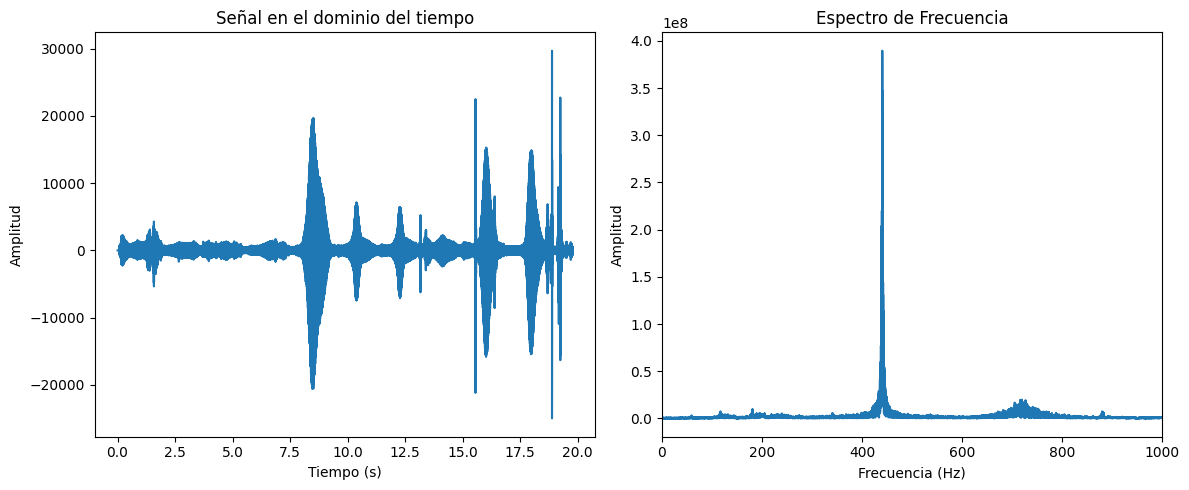

In [3]:
# Cargar el archivo de audio
sample_rate, data = wav.read("/content/Record-_online-voice-recorder.com_-_2_.wav")  # Reemplaza con tu archivo .wav

# Si el audio es estéreo, convertirlo a mono
if len(data.shape) > 1:
    data = data[:, 0]  # Tomar solo un canal

# Calcular la Transformada de Fourier (FFT)
n = len(data)
frequencies = np.fft.fftfreq(n, d=1/sample_rate)
fft_values = np.fft.fft(data)

# Graficar la señal en el tiempo
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0, n/sample_rate, num=n), data)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal en el dominio del tiempo")

# Graficar la magnitud de la FFT (solo la parte positiva)
plt.subplot(1, 2, 2)
plt.plot(frequencies[:n//2], np.abs(fft_values[:n//2]))  # Magnitud de la FFT
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.title("Espectro de Frecuencia")
plt.xlim(0, 1000)

plt.tight_layout()
plt.show()

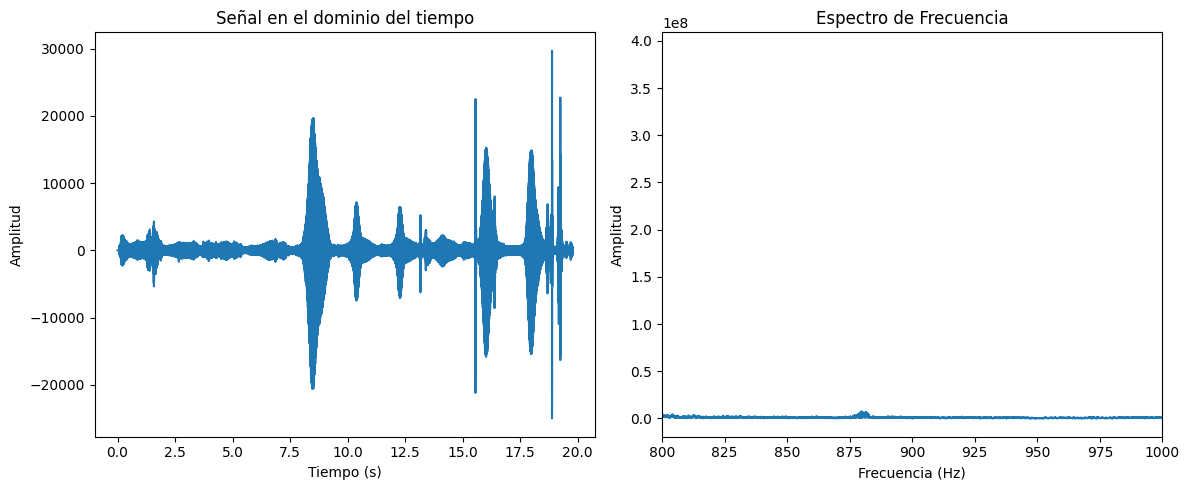

In [4]:
# Cargar el archivo de audio
sample_rate, data = wav.read("/content/Record-_online-voice-recorder.com_-_2_.wav")  # Reemplaza con tu archivo .wav

# Si el audio es estéreo, convertirlo a mono
if len(data.shape) > 1:
    data = data[:, 0]  # Tomar solo un canal

# Crear el eje de tiempo
n = len(data)
time = np.linspace(0, n/sample_rate, num=n)

# Calcular la Transformada de Fourier (FFT)
frequencies = np.fft.fftfreq(n, d=1/sample_rate)
fft_values = np.fft.fft(data)

# Graficar la señal en el dominio del tiempo
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(time, data)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal en el dominio del tiempo")

# Graficar la magnitud de la FFT (solo la parte positiva)
plt.subplot(1, 2, 2)
plt.plot(frequencies[:n//2], np.abs(fft_values[:n//2]))  # Magnitud de la FFT
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.title("Espectro de Frecuencia")
plt.xlim(800, 1000)  # Limitar al rango audible

plt.tight_layout()
plt.show()


<ipython-input-5-2ac9f4b40b9c>:39: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='inferno')


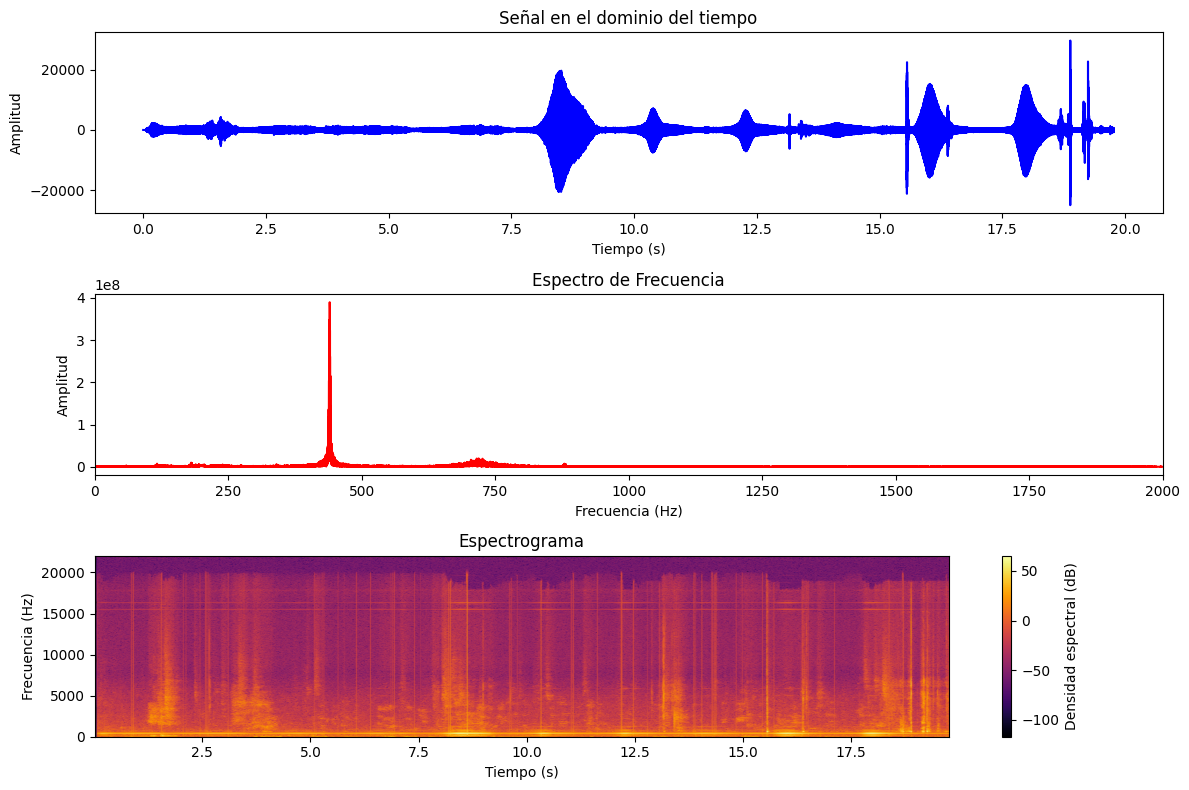

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import scipy.signal as signal

# Cargar el archivo de audio
sample_rate, data = wav.read("/content/Record-_online-voice-recorder.com_-_2_.wav")  # Reemplaza con tu archivo .wav

# Si el audio es estéreo, convertirlo a mono
if len(data.shape) > 1:
    data = data[:, 0]  # Tomar solo un canal

# Calcular la Transformada de Fourier (FFT)
n = len(data)
frequencies = np.fft.fftfreq(n, d=1/sample_rate)
fft_values = np.fft.fft(data)

# Crear la figura
plt.figure(figsize=(12, 8))

# Gráfico de la señal en el tiempo
plt.subplot(3, 1, 1)
plt.plot(np.linspace(0, n/sample_rate, num=n), data, color='b')
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal en el dominio del tiempo")

# Espectro de frecuencia (FFT)
plt.subplot(3, 1, 2)
plt.plot(frequencies[:n//2], np.abs(fft_values[:n//2]), color='r')  # Solo la parte positiva
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.title("Espectro de Frecuencia")
plt.xlim(0, 2000)  # Ajusta según el rango de interés

# Espectrograma
plt.subplot(3, 1, 3)
f, t, Sxx = signal.spectrogram(data, fs=sample_rate, nperseg=1024)
plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='inferno')
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.title("Espectrograma")
plt.colorbar(label="Densidad espectral (dB)")

plt.tight_layout()
plt.show()


<ipython-input-6-d1d9287531e1>:50: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='inferno')


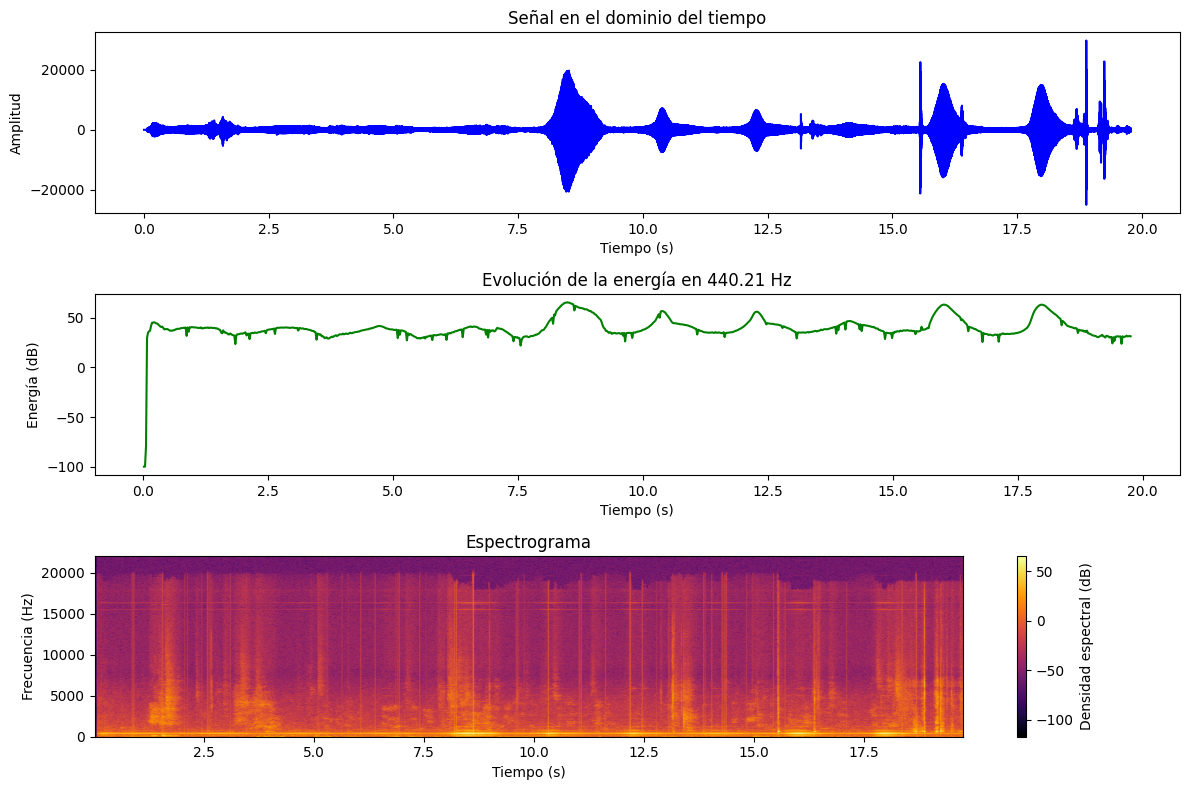

La frecuencia principal detectada es: 440.21 Hz


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import scipy.signal as signal

# Cargar el archivo de audio
sample_rate, data = wav.read("/content/Record-_online-voice-recorder.com_-_2_.wav")  # Reemplaza con tu archivo .wav

# Si el audio es estéreo, convertirlo a mono
if len(data.shape) > 1:
    data = data[:, 0]  # Tomar solo un canal

# Calcular la Transformada de Fourier (FFT)
n = len(data)
frequencies = np.fft.fftfreq(n, d=1/sample_rate)
fft_values = np.fft.fft(data)

# Encontrar la frecuencia dominante
idx_max = np.argmax(np.abs(fft_values[:n//2]))  # Índice del mayor pico en la FFT
freq_principal = frequencies[idx_max]

# Calcular el espectrograma
f, t, Sxx = signal.spectrogram(data, fs=sample_rate, nperseg=1024)

# Encontrar la evolución de la energía en la frecuencia dominante
idx_freq = np.argmin(np.abs(f - freq_principal))  # Índice de la frecuencia en el espectrograma
energy = Sxx[idx_freq, :]  # Energía en la frecuencia dominante

# Normalizar la energía para ver variaciones
energy_db = 10 * np.log10(energy + 1e-10)  # Convertir a dB para mejor visualización

# Graficar la señal en el tiempo
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(np.linspace(0, n/sample_rate, num=n), data, color='b')
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal en el dominio del tiempo")

# Graficar la energía en la frecuencia principal
plt.subplot(3, 1, 2)
plt.plot(t, energy_db, color='g')
plt.xlabel("Tiempo (s)")
plt.ylabel("Energía (dB)")
plt.title(f"Evolución de la energía en {freq_principal:.2f} Hz")

# Graficar el espectrograma
plt.subplot(3, 1, 3)
plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='inferno')
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.title("Espectrograma")
plt.colorbar(label="Densidad espectral (dB)")

plt.tight_layout()
plt.show()

# Mostrar la frecuencia dominante
print(f"La frecuencia principal detectada es: {freq_principal:.2f} Hz")


<ipython-input-7-8d4cbf86aa29>:61: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='inferno')


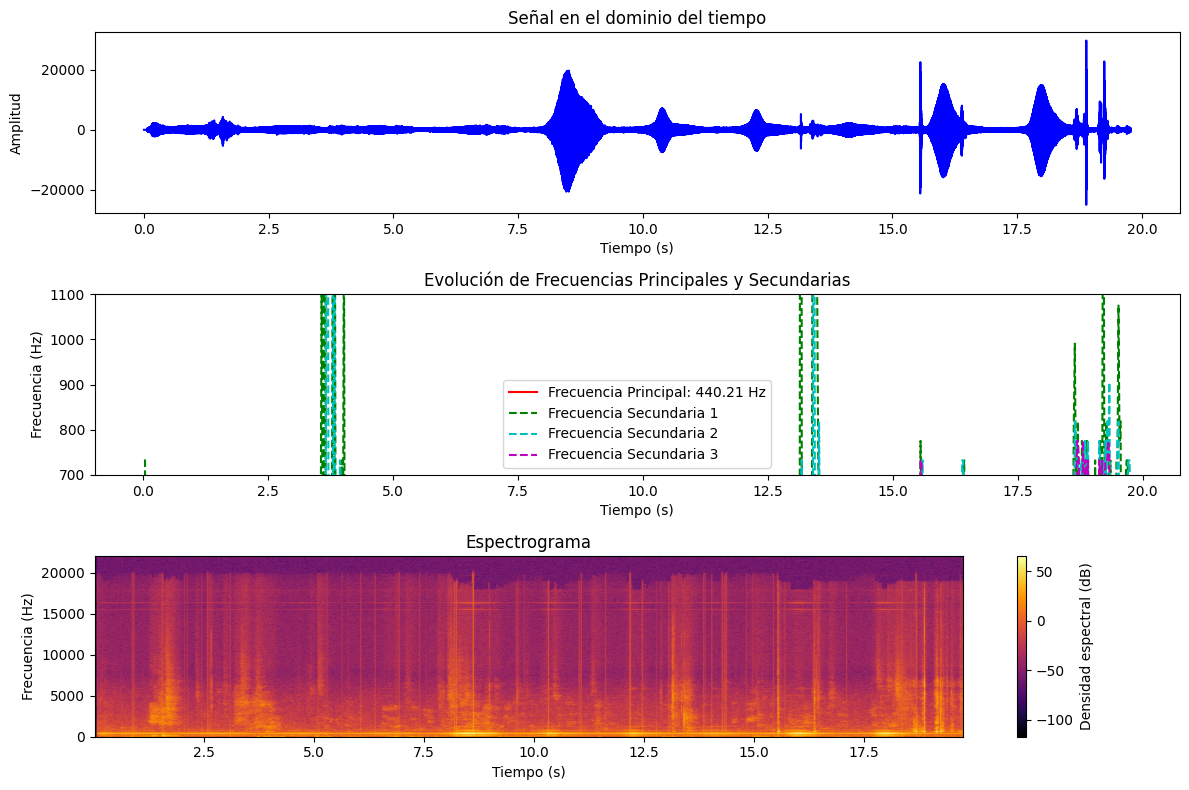

La frecuencia principal detectada es: 440.21 Hz
Frecuencias secundarias promedio detectadas: [499.49064186 467.79943233 432.2132138 ] Hz


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import scipy.signal as signal

# Cargar el archivo de audio
sample_rate, data = wav.read("/content/Record-_online-voice-recorder.com_-_2_.wav")  # Reemplaza con tu archivo .wav

# Si el audio es estéreo, convertirlo a mono
if len(data.shape) > 1:
    data = data[:, 0]  # Tomar solo un canal

# Calcular la FFT de la señal completa
n = len(data)
frequencies = np.fft.fftfreq(n, d=1/sample_rate)
fft_values = np.fft.fft(data)

# Encontrar la frecuencia principal
idx_max = np.argmax(np.abs(fft_values[:n//2]))
freq_principal = frequencies[idx_max]

# Calcular el espectrograma
f, t, Sxx = signal.spectrogram(data, fs=sample_rate, nperseg=1024)

# Identificar frecuencias secundarias en cada momento
num_peaks = 3  # Número de frecuencias secundarias a detectar
secundarias_por_tiempo = []

for i in range(len(t)):
    spectrum = Sxx[:, i]
    peak_indices = np.argsort(spectrum)[-num_peaks:]  # Obtener las 3 frecuencias más fuertes
    peak_freqs = f[peak_indices]
    secundarias_por_tiempo.append(peak_freqs)

# Convertir a matriz para graficar
secundarias_por_tiempo = np.array(secundarias_por_tiempo).T

# Graficar la señal en el tiempo
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(np.linspace(0, n/sample_rate, num=n), data, color='b')
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal en el dominio del tiempo")

# Graficar la evolución de la frecuencia principal y secundarias
plt.subplot(3, 1, 2)
plt.plot(t, [freq_principal] * len(t), label=f'Frecuencia Principal: {freq_principal:.2f} Hz', color='r')
plt.plot(t, secundarias_por_tiempo[0], label="Frecuencia Secundaria 1", linestyle="--", color='g')
plt.plot(t, secundarias_por_tiempo[1], label="Frecuencia Secundaria 2", linestyle="--", color='c')
plt.plot(t, secundarias_por_tiempo[2], label="Frecuencia Secundaria 3", linestyle="--", color='m')
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.ylim(700, 1100)
plt.title("Evolución de Frecuencias Principales y Secundarias")
plt.legend()

# Graficar el espectrograma
plt.subplot(3, 1, 3)
plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='inferno')
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.title("Espectrograma")
plt.colorbar(label="Densidad espectral (dB)")

plt.tight_layout()
plt.show()

# Mostrar la frecuencia principal y secundarias
print(f"La frecuencia principal detectada es: {freq_principal:.2f} Hz")
print(f"Frecuencias secundarias promedio detectadas: {np.mean(secundarias_por_tiempo, axis=1)} Hz")


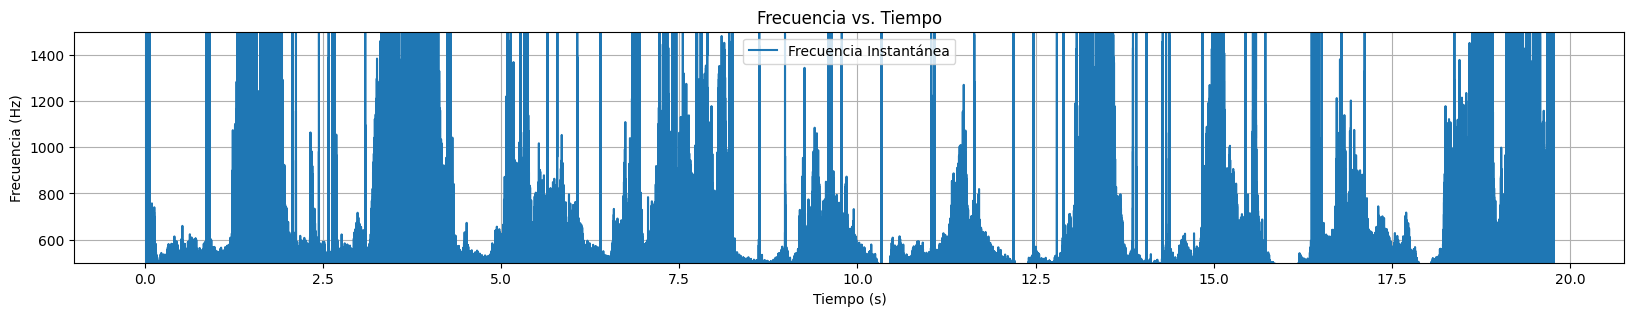

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.io import wavfile

# Cargar archivo de audio (reemplaza 'archivo.wav' con tu archivo)
fs, signal = wavfile.read("/content/Record-_online-voice-recorder.com_-_2_.wav")

# Si la señal es estéreo, convertir a mono
if len(signal.shape) > 1:
    signal = signal.mean(axis=1)

# Aplicar la Transformada de Hilbert
analytic_signal = hilbert(signal)
instantaneous_phase = np.unwrap(np.angle(analytic_signal))
instantaneous_frequency = np.diff(instantaneous_phase) * fs / (2.0 * np.pi)

# Crear vector de tiempo para graficar (ajustado porque diff reduce el tamaño)
time = np.arange(len(instantaneous_frequency)) / fs

# Graficar frecuencia vs. tiempo
plt.figure(figsize=(20, 3))
plt.plot(time, instantaneous_frequency, label="Frecuencia Instantánea")
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.title("Frecuencia vs. Tiempo")
plt.ylim(500,1500)
#plt.xlim(0.1,6)
plt.legend()
plt.grid()
plt.show()


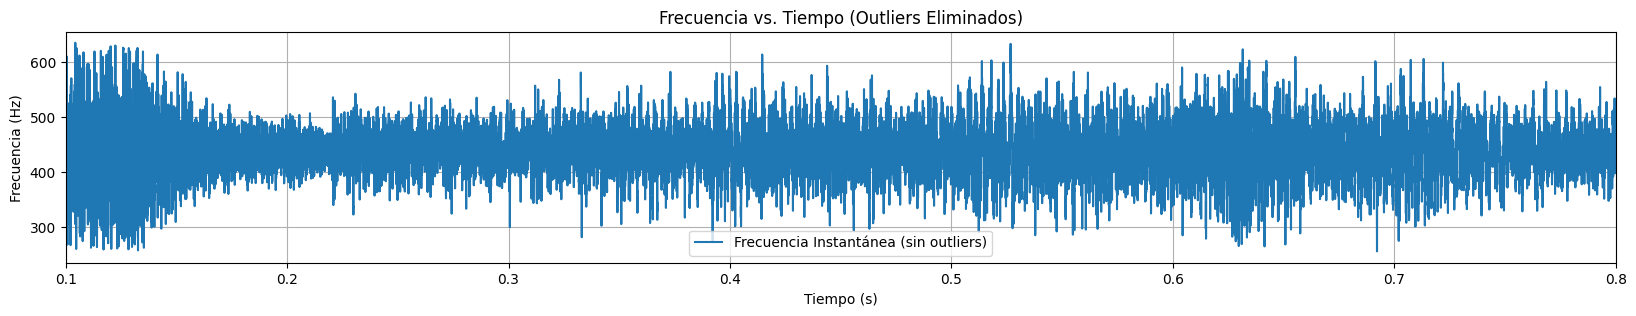

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.io import wavfile

# Cargar archivo de audio
fs, signal = wavfile.read("/content/Record-_online-voice-recorder.com_-_2_.wav")

# Si la señal es estéreo, convertir a mono
if len(signal.shape) > 1:
    signal = signal.mean(axis=1)

# Aplicar la Transformada de Hilbert
analytic_signal = hilbert(signal)
instantaneous_phase = np.unwrap(np.angle(analytic_signal))
instantaneous_frequency = np.diff(instantaneous_phase) * fs / (2.0 * np.pi)

# Crear vector de tiempo para graficar
time = np.arange(len(instantaneous_frequency)) / fs

# 📌 Calcular los cuartiles
Q1 = np.percentile(instantaneous_frequency, 25)
Q3 = np.percentile(instantaneous_frequency, 75)
IQR = Q3 - Q1

# 📌 Definir los límites para outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 📌 Filtrar los datos eliminando outliers
mask = (instantaneous_frequency >= lower_bound) & (instantaneous_frequency <= upper_bound)
filtered_time = time[mask]
filtered_frequency = instantaneous_frequency[mask]

# 📌 Graficar frecuencia vs. tiempo después de eliminar outliers
plt.figure(figsize=(20, 3))
plt.plot(filtered_time, filtered_frequency, label="Frecuencia Instantánea (sin outliers)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.title("Frecuencia vs. Tiempo (Outliers Eliminados)")
plt.legend()
plt.xlim(0.1,0.8)
plt.grid()
plt.show()


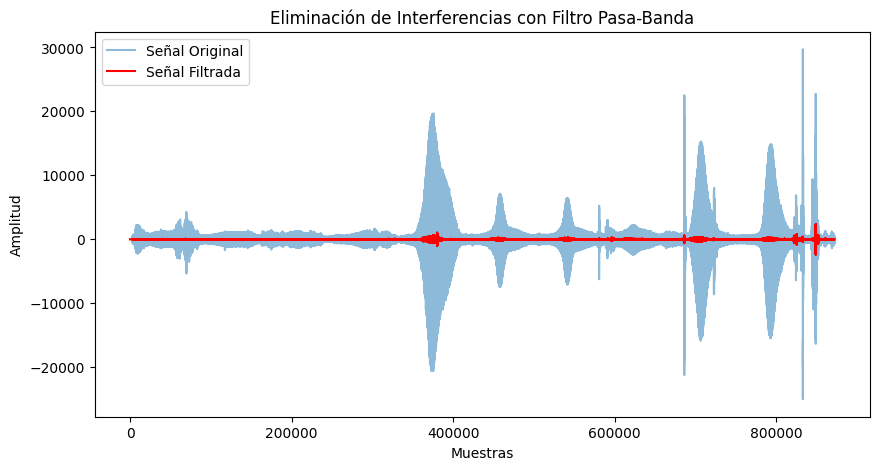

In [11]:
from scipy.signal import butter, filtfilt
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# 📌 Cargar el archivo de audio
fs, signal = wavfile.read("/content/Record-_online-voice-recorder.com_-_2_.wav")

# Convertir a mono si es necesario
if len(signal.shape) > 1:
    signal = signal.mean(axis=1)

# 📌 Definir un filtro pasa-banda (ejemplo: 800 Hz - 1200 Hz)
lowcut = 850  # Frecuencia mínima (Hz)
highcut = 950  # Frecuencia máxima (Hz)

# 📌 Diseñar un filtro Butterworth de orden 4
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

# 📌 Aplicar el filtro a la señal
b, a = butter_bandpass(lowcut, highcut, fs)
filtered_signal = filtfilt(b, a, signal)

# 📌 Graficar señal original vs filtrada
plt.figure(figsize=(10, 5))
plt.plot(signal, alpha=0.5, label="Señal Original")
plt.plot(filtered_signal, label="Señal Filtrada", color='red')
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.legend()
plt.title("Eliminación de Interferencias con Filtro Pasa-Banda")
plt.show()


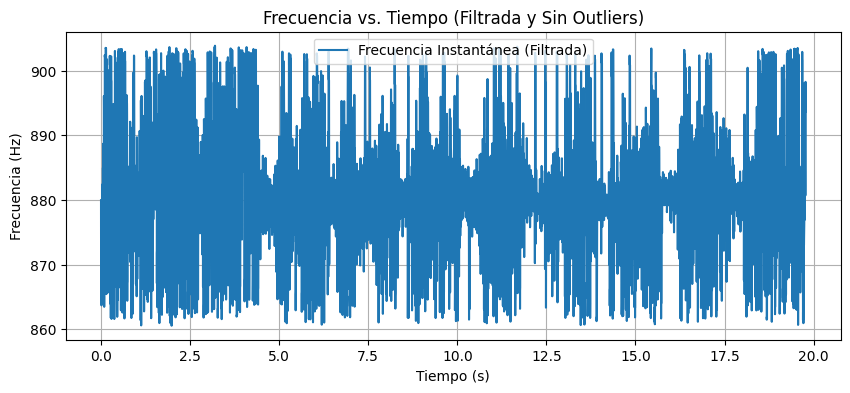

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, filtfilt
from scipy.io import wavfile
from scipy.fft import fft, ifft, fftfreq

# 📌 1. Cargar archivo de audio
fs, signal = wavfile.read("/content/Record-_online-voice-recorder.com_-_2_.wav")
if len(signal.shape) > 1:
    signal = signal.mean(axis=1)  # Convertir a mono si es estéreo

# 📌 2. Filtro Pasa-Banda (Butterworth) para eliminar ruido fuera del rango útil
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low, high = lowcut / nyquist, highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

b, a = butter_bandpass(850, 950, fs)
filtered_signal = filtfilt(b, a, signal)

# 📌 3. FFT para eliminar interferencias en 60 Hz (ruido eléctrico)
n = len(filtered_signal)
frequencies = fftfreq(n, d=1/fs)
fft_values = fft(filtered_signal)
fft_values[np.abs(frequencies - 60) < 5] = 0  # Anular 60 Hz y cercanas
clean_signal = ifft(fft_values).real

# 📌 4. Transformada de Hilbert para obtener frecuencia instantánea
analytic_signal = hilbert(clean_signal)
instantaneous_phase = np.unwrap(np.angle(analytic_signal))
instantaneous_frequency = np.diff(instantaneous_phase) * fs / (2.0 * np.pi)
time = np.arange(len(instantaneous_frequency)) / fs

# 📌 5. Eliminación de Outliers con Cuartiles
Q1, Q3 = np.percentile(instantaneous_frequency, [25, 75])
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
mask = (instantaneous_frequency >= lower_bound) & (instantaneous_frequency <= upper_bound)
filtered_time, filtered_frequency = time[mask], instantaneous_frequency[mask]

# 📌 6. Suavizar la frecuencia instantánea con media móvil
window_size = 50
smoothed_frequency = np.convolve(filtered_frequency, np.ones(window_size)/window_size, mode='valid')

# 📌 7. Graficar Frecuencia vs Tiempo después de filtrar
plt.figure(figsize=(10, 4))
plt.plot(filtered_time[:len(smoothed_frequency)], smoothed_frequency, label="Frecuencia Instantánea (Filtrada)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.title("Frecuencia vs. Tiempo (Filtrada y Sin Outliers)")

plt.legend()
plt.grid()
plt.show()